### Run this to add the model to nobackup
just run 
source setup.sh in the terminal

### Load the model 

In [1]:
import open_clip
import torch
 
# Load ViT-B/32 with OpenAI pretrained weights (downloads once, then cached)
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

 
print(f"Model loaded on: {device}")
print(f"Image preprocessing: {preprocess}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

/nobackup/anthu456/clip_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nobackup/anthu456/clip_venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Model loaded on: cuda
Image preprocessing: Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=warn)
    CenterCrop(size=(224, 224))
    <function _convert_to_rgb at 0x7fd4251f8f70>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)
Model parameters: 151,277,313


### dataset

playing around with the data. use this block to see how the data is structured

In [2]:
import json

with open("data/dataset_rsicd.json", "r") as f:
    data = json.load(f)
images = data["images"][0]
dataset = data["dataset"][-1]


# print(json.dumps(images, indent=2))
# caption_counts = [len(img["sentences"]) for img in data["images"]]
# print(images["split"])
k = data["images"][6230]
print(k["split"])

val


#### split the data into training, valiadtion and test

In [3]:
data_a = [i for i in data["images"] if i["split"] == "train"]
data_b = [i for i in data["images"] if i["split"] == "val"]
data_c = [i for i in data["images"] if i["split"] == "test"]

print(len(data_a))
print(len(data_b))
print(len(data_c))


#data_a[25]['sentences']


8734
1094
1093


In [4]:
! pip install matplotlib

### Get an image and the captions

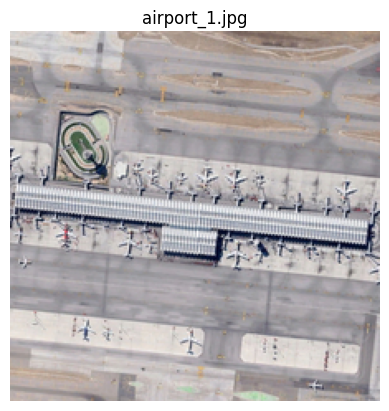

- many planes are parked next to a long building in an airport .
- many planes are parked next to a long building in an airport .
- many planes are parked next to a long building in an airport .
- many planes are parked next to a long building in an airport .
- many planes are parked next to a long building in an airport .


In [5]:
from PIL import Image
import matplotlib.pyplot as plt

example = data_a[0]
img = Image.open(f"data/RSICD_images/{example['filename']}")

plt.imshow(img)
plt.title(example["filename"])
plt.axis("off")
plt.show()

for s in example["sentences"]:
    print(f"- {s['raw']}")

In [6]:
import os
print(os.listdir("data/"))
missing = [img["filename"] for img in data_c if not os.path.exists(f"data/RSICD_images/{img['filename']}")]
print(f"Missing: {len(missing)} out of {len(data_c)}")
print(f"Total images: {len(os.listdir('data/RSICD_images'))}")

['txtclasses_rsicd', 'RSICD_images', 'Leaderboard_data', 'dataset_rsicd.json']
Missing: 0 out of 1093
Total images: 10921


In [7]:
pairs = []
for img in data_b:
    path = f"data/RSICD_images/{img['filename']}"
    if os.path.exists(path):
        for sent in img["sentences"]:
            pairs.append((path, sent["raw"]))
#print(pairs)
#print(f"Total training pairs: {len(pairs)}")


In [8]:
!pip install scikit-learn

In [9]:
from sklearn.model_selection import train_test_split

image_files = list(set([p[0] for p in pairs]))
train_imgs, val_imgs = train_test_split(image_files, test_size=0.2, random_state=42) # 80 procent training, 

train_pairs = [(p, c) for p, c in pairs if p in set(train_imgs)]
val_pairs = [(p, c) for p, c in pairs if p in set(val_imgs)]

### lets start with the embeddings

each image has the shape torch.Size([1, 3, 224, 224])
and the text has (training data right now) [1639 ,77] meaning we have [num text, tokens], 77 is the max and whats left after tokenisation will be padded

In [10]:
from rsiddataset import RSIDCDataset
from torch.utils.data import DataLoader

#%pip uninstall -y numpy

# 2. Install the latest compatible version
#%pip install "numpy<2.0.0"

batch_size = 8
train_dataload = RSIDCDataset(pairs =train_pairs, preprocess=preprocess, tokenizer=tokenizer)
val_dataload = RSIDCDataset(pairs =val_pairs, preprocess=preprocess, tokenizer=tokenizer)
image = preprocess(Image.open(f"data/RSICD_images/{example['filename']}")).unsqueeze(0)
train = DataLoader(train_dataload, batch_size=batch_size, shuffle = True) # shuffle makes us shuffle data each epoch 
val =  DataLoader(val_dataload, batch_size=batch_size, shuffle = False) 



### Training loop 

some nice things to know, i know Dr J.AlmQ doesent like messy notebooks so i remove all my prints from the block and add important stuff here. 

images.shape   # (8, 3, 224, 224)

tokens.shape   # (8, 77)

image = model.encode_image(images)  has shape ([8, 512])

text  = model.encode_text(tokens) # ([8, 512])

calc = image @text.T  # [8, 512] @ [512,8] = [8,8] so a predictino for each batch



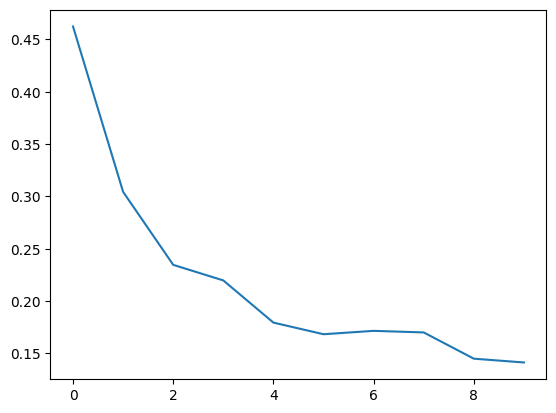

In [11]:

loss_func = torch.nn.functional.cross_entropy
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
loss_list = []
epochs = 10 
for i in range(epochs):
    epoch_loss = 0
    for images, tokens in train:
        optimizer.zero_grad()
        labels = torch.arange(images.shape[0]).to(device)
        images = images.to(device)
        tokens = tokens.to(device)
        image = model.encode_image(images) # ([8, 512])
        text  = model.encode_text(tokens) # ([8, 512])
        logit_scale = model.logit_scale.exp() # use for scaling
        image = image / image.norm(dim=-1, keepdim=True) # normalize
        text = text / text.norm(dim=-1, keepdim=True)   
        pred = logit_scale * image @ text.T # [8, 512] @ [512,8] = [8,8] so a predictino for each batch
        loss = loss_func(pred,labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train)
    loss_list.append(avg_loss)

plt.plot(loss_list)
plt.show()

## Text-to-Image evaluation

This part evaluates how well the model can predict which image belongs to which caption by computing and comparing the embeddings, thereafter using Recall@K to compute the recall.

### Math for cosine similarity and recall


Cosine similarity: If the text matrix is $Q$ and the image matrix is $G$, the similarity for every possible pair is $S = Q \times G^T$

Recall: $$R@K = \frac{1}{N_q} \sum_{i=1}^{N_q} \mathbb{1}(GT_i \in TopK(i))$$Where $\mathbb{1}$ is the indicator function (1 if true, 0 if false) and $N_q$ is the total number of queries (5,465).

In [ ]:
#Store embeddings
image_embeddings = []
caption_embeddings = []

#Compute embeddings for images and captions in test data
model.eval()
for img_entry in data_c:
    filename = img_entry["filename"]
    image_path = f"data/RSICD_images/{filename}"
    #class_label = filename.split('_')[0] 

    #Image embeddings
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        image_embedding = model.encode_image(image)
    image_embedding /= image_embedding.norm(dim=-1, keepdim=True)
    image_embeddings.append(image_embedding.cpu())

    #Caption embeddings
    for caption in img_entry["sentences"]:
        #print("caption is: ", caption)
        with torch.no_grad():
            tokens = tokenizer(caption["raw"]).to(device)
            current_caption  = model.encode_text(tokens)
        current_caption = current_caption / current_caption.norm(dim=-1, keepdim=True) 
        caption_embeddings.append(current_caption.cpu())

#print(f"Successfully paired {len(image_embeddings)} images for Split C.")
#print("\n")
#print("Len image embeddings: ", len(image_embeddings))
#print("Len caption embeddings: ", len(caption_embeddings))
#print(split_c_data)

#Concat embeddings
image_embeddings = torch.cat(image_embeddings)
caption_embeddings = torch.cat(caption_embeddings)

#Cosine similarity:
cos_similarity = caption_embeddings @ image_embeddings.T

#Ground truth:
target_list = []
for i in range(len(image_embeddings)):
    for j in range(0,5):
        target_list.append(i)
#print(target_list)
target_tensor = torch.Tensor(target_list)

#print("Shape img embds: ", image_embeddings.shape)
#print("Shape capt embds: ", caption_embeddings.shape)

#Compute TopK=10
topk10_values, topk10_indices = torch.topk(cos_similarity, k=10, dim=1)

#Count top10, top5 and top1
recall10 = 0
recall5 = 0
recall1 = 0
failed = []
for i in range(len(target_tensor)):
    if target_tensor[i] in topk10_indices[i,:10]:
        recall10 += 1
    if target_tensor[i] in topk10_indices[i,:5]:
        recall5 += 1
    if target_tensor[i] in topk10_indices[i,0]:
        recall1 += 1
    else:
        if len(failed) <= 10:
            temp = [i//5, i%5, topk10_indices[i,0]] #correct image, caption, predicted failed image
            failed.append(temp)

#Compute recall
recall10_rate = recall10/len(caption_embeddings)
recall5_rate = recall5/len(caption_embeddings)
recall1_rate = recall1/len(caption_embeddings)

#Print recall
print("Recall@10 rate: ", recall10_rate)
print("Recall@5 rate: ", recall5_rate)
print("Recall@1 rate: ", recall1_rate)
print("\n")



Successfully paired 1093 images for Split C.


Recall@10 rate:  0.28435498627630373
Recall@5 rate:  0.1666971637694419
Recall@1 rate:  0.03989021043000915




## Test - Correct image vs predicted image for captions

In [ ]:
for i in range(len(failed)):
    failed_image = data_c[failed[i][0]]
    failed_caption = data_c[failed[i][1]]
    failed_guessed_image = data_c[failed[i][2]]

    print(f"Failure #{i}:")

    print("The correct image was:")
    example = failed_image
    img = Image.open(f"data/RSICD_images/{example['filename']}")
    plt.imshow(img)
    plt.title(example["filename"])
    plt.axis("off")
    plt.show()

    print("The caption was:")
    print(data_c[failed[i][0]]['sentences'][failed[i][1]]['raw'])

    print("The failed guessed image was:")
    example = failed_guessed_image
    img = Image.open(f"data/RSICD_images/{example['filename']}")
    plt.imshow(img)
    plt.title(example["filename"])
    plt.axis("off")
    plt.show()
    print("\n")


'\nfor i in range(len(failed)):\n    failed_image = data_c[failed[i][0]]\n    failed_caption = data_c[failed[i][1]]\n    failed_guessed_image = data_c[failed[i][2]]\n\n    print(f"Failure #{i}:")\n\n    print("The correct image was:")\n    example = failed_image\n    img = Image.open(f"data/RSICD_images/{example[\'filename\']}")\n    plt.imshow(img)\n    plt.title(example["filename"])\n    plt.axis("off")\n    plt.show()\n\n    print("The caption was:")\n    print(data_c[failed[i][0]][\'sentences\'][failed[i][1]][\'raw\'])\n\n    print("The failed guessed image was:")\n    example = failed_guessed_image\n    img = Image.open(f"data/RSICD_images/{example[\'filename\']}")\n    plt.imshow(img)\n    plt.title(example["filename"])\n    plt.axis("off")\n    plt.show()\n    print("\n")\n'

## Test hand-written prompts

Prompt is:  bridge with grass around the water
Predicted image is: 


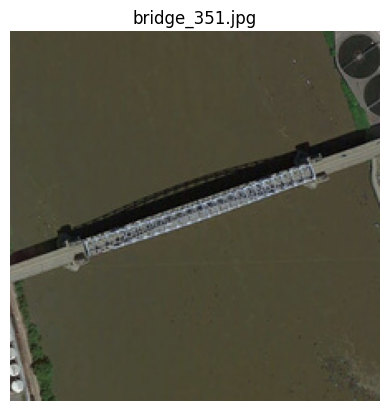

In [48]:
#Change the prompt below to anything and run
prompt = "bridge with grass around the water"

with torch.no_grad():
    tokens = tokenizer(prompt).to(device)
    prompt_embeddings  = model.encode_text(tokens).to(device)
    prompt_embeddings = prompt_embeddings / prompt_embeddings.norm(dim=-1, keepdim=True)

cos_similarity = prompt_embeddings.to(device) @ image_embeddings.T.to(device)
topk1_value, topk1_index = torch.topk(cos_similarity, k=1, dim=1)


print("Prompt is: ", prompt)
print("Predicted image is: ")
img_data = data_c[topk1_index.item()]
img = Image.open(f"data/RSICD_images/{img_data['filename']}")
plt.imshow(img)
plt.title(img_data["filename"])
plt.axis("off")
plt.show()